# BERT for Sentiment Analysis

## 1. Setup

In [1]:
!pip install -q transformers datasets wandb scikit-learn accelerate tabulate

In [2]:
import os
import gc
import time
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import wandb

from config import SEED, NUM_LABELS, WANDB_PROJECT, REPORT_TO
from data_pipeline import set_seed, load_and_split, prepare_transformer_dataset

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibility
set_seed(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.mem_get_info(0)[1] / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM: 11.3 GB


In [4]:
# wandb login
wandb.login()
os.environ["WANDB_PROJECT"] = WANDB_PROJECT

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: thanigaiarasushanmugam (thanigaiarasushanmugam-thani) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Model & Tokenizer

In [5]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## 3. Metrics & Training Function

In [6]:
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [7]:
def train_and_evaluate(subset_size=None, filepath=None, num_epochs=3,
                       batch_size=16, learning_rate=2e-5, run_name="bert"):
    """Train BERT and evaluate on test set"""

    # Load and tokenize data
    print(f"Loading data (subset_size={subset_size}, filepath={filepath})...")
    splits = load_and_split(subset_size=subset_size, filepath=filepath)
    print(f"  Train: {len(splits['train']['texts'])}, "
          f"Val: {len(splits['val']['texts'])}, "
          f"Test: {len(splits['test']['texts'])}")

    print("Tokenizing...")
    train_ds = prepare_transformer_dataset(
        splits["train"]["texts"], splits["train"]["labels"], MODEL_NAME
    )
    val_ds = prepare_transformer_dataset(
        splits["val"]["texts"], splits["val"]["labels"], MODEL_NAME
    )
    test_ds = prepare_transformer_dataset(
        splits["test"]["texts"], splits["test"]["labels"], MODEL_NAME
    )

    # Free raw text from memory
    del splits
    gc.collect()

    # Load fresh model for each run
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )

    # Calculate warmup steps (10% of total training steps)
    total_steps = (len(train_ds) // batch_size // 2) * num_epochs
    warmup_steps = int(total_steps * 0.1)

    # Training arguments
    args = TrainingArguments(
        output_dir=f"./results/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=2,           
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_steps=warmup_steps,
        fp16=True,                               
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        report_to=REPORT_TO,
        run_name=run_name,
        seed=SEED,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # Train
    print(f"Training ({num_epochs} epochs, warmup={warmup_steps} steps)...")
    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.1f}s")

    # Save log history for plotting
    log_history = trainer.state.log_history

    # Evaluate on test set using predict
    print("Evaluating on test set...")
    test_output = trainer.predict(test_ds)
    test_results = test_output.metrics
    test_results["training_time_seconds"] = training_time
    test_results["subset_size"] = subset_size
    test_results["filepath"] = filepath
    test_results["num_epochs"] = num_epochs
    test_results["log_history"] = log_history

    # Print results
    print(f"\n--- Results ({run_name}) ---")
    print(f"Accuracy:  {test_results['test_accuracy']:.4f}")
    print(f"Precision: {test_results['test_precision']:.4f}")
    print(f"Recall:    {test_results['test_recall']:.4f}")
    print(f"F1:        {test_results['test_f1']:.4f}")
    print(f"Time:      {training_time:.1f}s")

    # Cleanup GPU memory
    wandb.finish()
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return test_results

## 4. Training

In [8]:
# Run 1: 1K given dataset — baseline comparison
results_1k = train_and_evaluate(
    filepath="data/amazon_cells_labelled.txt",
    num_epochs=5,
    run_name="bert_1k",
)

Loading data (subset_size=None, filepath=data/amazon_cells_labelled.txt)...
  Train: 800, Val: 100, Test: 100
Tokenizing...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6702.86it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Training (5 epochs, warmup=12 steps)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.456902,0.900000,0.870370,0.940000,0.903846
2,0.896436,0.172371,0.940000,0.940000,0.940000,0.940000
3,0.896436,0.182011,0.940000,0.923077,0.960000,0.941176
4,0.179022,0.197099,0.920000,0.920000,0.920000,0.920000
5,0.179022,0.185377,0.930000,0.921569,0.940000,0.930693


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.84s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training completed in 43.5s
Evaluating on test set...



--- Results (bert_1k) ---
Accuracy:  0.9100
Precision: 0.9020
Recall:    0.9200
F1:        0.9109
Time:      43.5s


eval/accuracy,▁██▅▆
eval/f1,▁██▄▆
eval/loss,█▁▁▂▁
eval/precision,▁█▆▆▆
eval/recall,▅▅█▁▅
eval/runtime,█▂▂▁▁
eval/samples_per_second,▁▇▇██
eval/steps_per_second,▁▇▇██
test/accuracy,▁
test/f1,▁
+11,...


In [9]:
results_full = train_and_evaluate(
    subset_size=2800000,
    num_epochs=3,
    run_name="bert_2.8m",
)

Loading data (subset_size=2800000, filepath=None)...
  Train: 2240000, Val: 280000, Test: 280000
Tokenizing...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6245.73it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Training (3 epochs, warmup=21000 steps)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.230885,0.115881,0.959943,0.957737,0.962374,0.960050
2,0.223044,0.112790,0.962921,0.966174,0.959454,0.962802
3,0.170491,0.134961,0.963082,0.964721,0.961339,0.963027


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training completed in 41524.1s
Evaluating on test set...



--- Results (bert_2.8m) ---
Accuracy:  0.9638
Precision: 0.9647
Recall:    0.9629
F1:        0.9638
Time:      41524.1s


eval/accuracy,▁██
eval/f1,▁▇█
eval/loss,▂▁█
eval/precision,▁█▇
eval/recall,█▁▆
eval/runtime,█▁▁
eval/samples_per_second,▁██
eval/steps_per_second,▁██
test/accuracy,▁
test/f1,▁
+11,...


## 5. Results Summary

In [10]:
import pandas as pd

all_results = [results_1k, results_full]
exp_labels = ["1K / 5 epochs", "Full 2.8M / 3 epochs"]
summary = pd.DataFrame([
    {
        "Experiment": exp_labels[i],
        "Accuracy": round(r["test_accuracy"], 4),
        "Precision": round(r["test_precision"], 4),
        "Recall": round(r["test_recall"], 4),
        "F1": round(r["test_f1"], 4),
        "Time (s)": round(r["training_time_seconds"], 1),
    }
    for i, r in enumerate(all_results)
])
print(summary.to_markdown(index=False))

| Experiment           |   Accuracy |   Precision |   Recall |     F1 |   Time (s) |
|:---------------------|-----------:|------------:|---------:|-------:|-----------:|
| 1K / 5 epochs        |     0.91   |      0.902  |   0.92   | 0.9109 |       43.5 |
| Full 2.8M / 3 epochs |     0.9638 |      0.9647 |   0.9629 | 0.9638 |    41524.1 |


## 6. Plots

In [11]:
import matplotlib.pyplot as plt

def extract_metrics(log_history):
    """Extract per-epoch train loss, val loss, and eval metrics from log history."""
    train_losses = []
    val_losses = []
    eval_acc = []
    eval_f1 = []
    epochs = []

    for entry in log_history:
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])
            eval_acc.append(entry.get("eval_accuracy", None))
            eval_f1.append(entry.get("eval_f1", None))
            epochs.append(entry["epoch"])
        if "loss" in entry and "eval_loss" not in entry:
            train_losses.append(entry["loss"])

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "eval_acc": eval_acc,
        "eval_f1": eval_f1,
        "epochs": epochs,
    }

### 6.1 Training & Validation Loss per Epoch

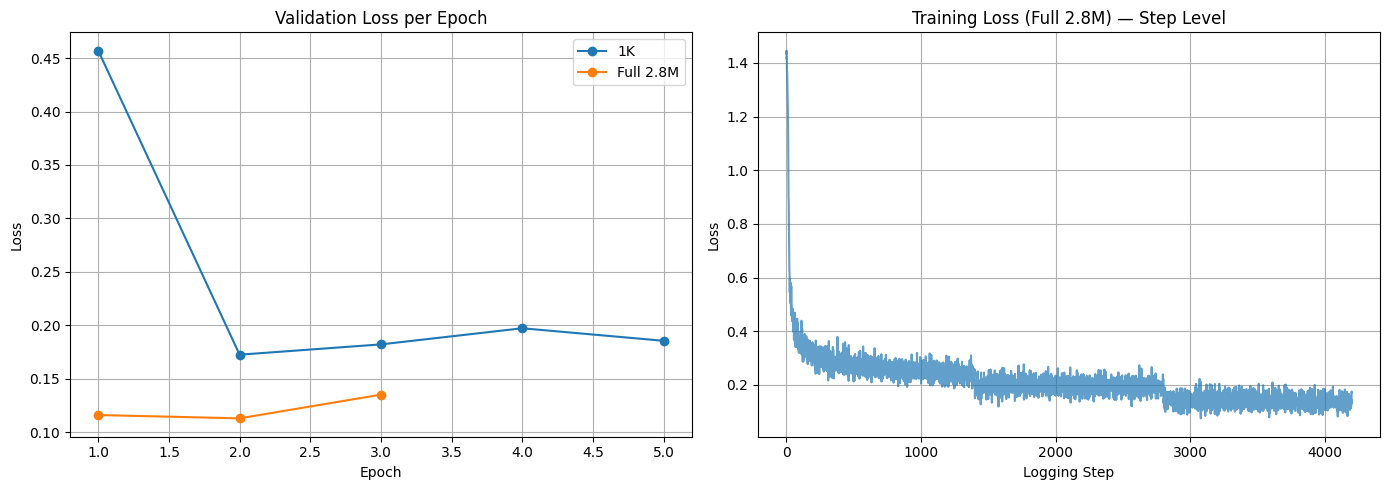

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results, label in [(results_1k, "1K"), (results_full, "Full 2.8M")]:
    m = extract_metrics(results["log_history"])

    # Validation loss per epoch
    axes[0].plot(m["epochs"], m["val_losses"], marker="o", label=label)

axes[0].set_title("Validation Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Training loss (step-level) for full dataset
m_full = extract_metrics(results_full["log_history"])
axes[1].plot(m_full["train_losses"], alpha=0.7)
axes[1].set_title("Training Loss (Full 2.8M) — Step Level")
axes[1].set_xlabel("Logging Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/loss_curves.png", dpi=150)
plt.show()

### 6.2 Validation Accuracy & F1 per Epoch

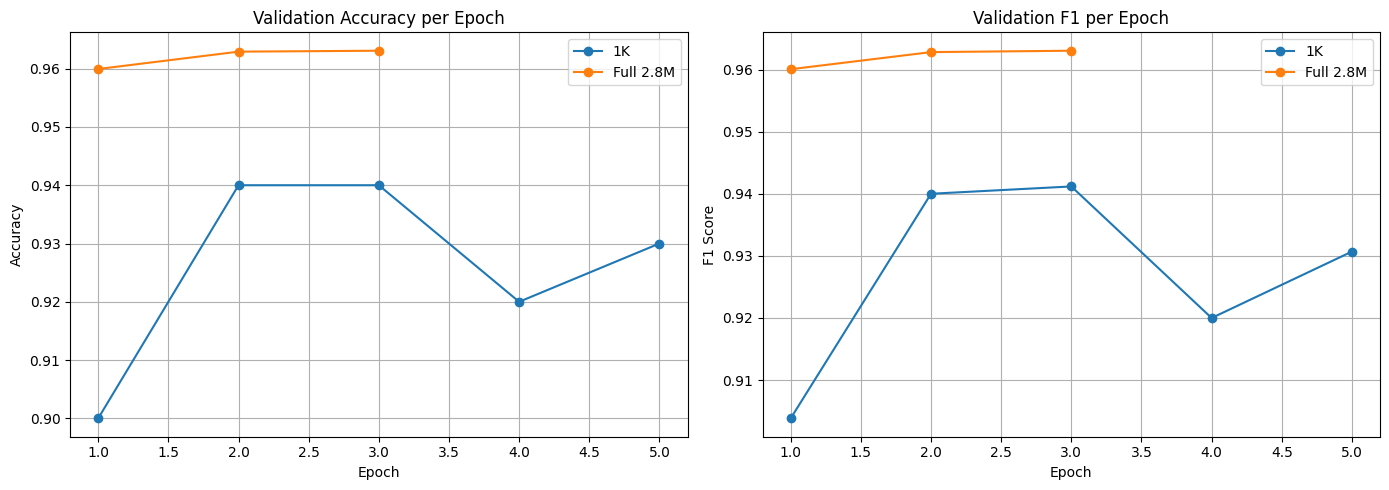

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results, label in [(results_1k, "1K"), (results_full, "Full 2.8M")]:
    m = extract_metrics(results["log_history"])

    axes[0].plot(m["epochs"], m["eval_acc"], marker="o", label=label)
    axes[1].plot(m["epochs"], m["eval_f1"], marker="o", label=label)

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation F1 per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/accuracy_f1_curves.png", dpi=150)
plt.show()

## 7. Analysis & Conclusions

### Convergence
- **1K dataset:** Training loss dropped significantly from 0.896 to 0.179 over 5 epochs, showing the model learned from the data. Validation loss reached its minimum at epoch 2 (0.172). The model converged early due to the small dataset size (only 800 training samples).
- **2.8M dataset:** Training loss decreased steadily from 0.231 to 0.170 over 3 epochs, indicating the model was still learning. Validation loss reached its minimum at epoch 2 (0.113). The model converged by epoch 2.

### Overfitting
- **1K dataset:** After epoch 2, validation loss increased from 0.172 to 0.197 (epoch 4) while training loss kept decreasing. Validation accuracy dropped from 94% to 92%. This confirms overfitting — with only 800 training samples, BERT memorized the data.
- **2.8M dataset:** Validation loss increased from 0.113 (epoch 2) to 0.135 (epoch 3), a 19% increase, while training loss continued to decrease (0.223 to 0.170). This is an early sign of overfitting even with 2.8M data, showing that 3 epochs may be slightly too many. However, validation accuracy remained stable at 96.3%, so the impact on performance is minimal.

### Data Scaling Impact
- Increasing data from 1K to 2.8M improved test accuracy from 91.0% to 96.4% (+5.4%) and test F1 from 91.1% to 96.4% (+5.3%).
- The 2.8M model achieves balanced precision (96.5%) and recall (96.3%), while the 1K model shows slight imbalance (precision 90.2% vs recall 92.0%), suggesting the smaller dataset does not represent both classes equally well.
- Even with fewer epochs (3 vs 5), the larger dataset produces a significantly better model. This confirms that for transformer models, data quantity matters more than training duration.

### Learning Rate Schedule
- We used a linear warmup (10% of total steps) followed by linear decay. This prevents instability in early training when gradients are large, and gradually reduces the learning rate as the model converges.

### Best Model Selection
- load_best_model_at_end=True with metric_for_best_model=eval_loss and greater_is_better=False ensures we always select the checkpoint with the lowest validation loss. This picks the epoch 2 model for both runs, avoiding the slight overfitting observed in later epochs.
